In [1]:
# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Dataset Source: https://www.kaggle.com/datasets/lodetomasi1995/income-classification

Informasi:
- Dataset yang digunakan untuk latihan gunakan hasil dari Question Creation dibawah.

# **Question Creation**

In [2]:
# Importing the dataset with pandas and separator is comma

url = 'income_evaluation_dataset.csv'
df = pd.read_csv(url,
                 sep=',',
                 encoding='latin-1',  # or encoding='ISO-8859-1'
                 parse_dates=[0])

C:\Users\kanek\AppData\Local\Temp\ipykernel_6424\1514184954.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(url,


In [3]:
# overview of the dataset

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
# checking the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  object
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(5), object(10)
memory usage: 3.7+ MB


In [5]:
# Mengganti nama kolom dan menghapus spasi
df.columns = df.columns.str.replace(' ', '')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  object
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(5), object(10)
memory usage: 3.7+ MB


In [37]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [38]:
# Change Missing Value to Median and Mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode().values[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
df['age'].fillna(df['age'].median(), inplace=True)

In [6]:
# Checking for the maximum and minimum values of the fnlwgt column
print("Nilai fnlwgt : ",df['fnlwgt'].max())
print("Nilai fnlwgt : ",df['fnlwgt'].min())

Nilai fnlwgt :  1484705
Nilai fnlwgt :  12285


In [7]:
# Changing fnlwgt from numeric to categorical

jumlah_kelas = 10 # jumlah kelas yang diinginkan
rentang_data = (df['fnlwgt'].min(), df['fnlwgt'].max()) # rentang data yang tersedia dengan range max - min
bins = np.linspace(rentang_data[0], rentang_data[1], jumlah_kelas + 1) # membuat bins dengan jarak yang sama unutk setiap kelas
labels = ['exceptionally low', 'exceedingly low', 'subdued', 'somewhat low', 'medium', 'somewhat high', 'elevated', 'highly elevated', 'exceptionally high', 'ultra-high']

# Gunakan pd.cut untuk membagi data menjadi kategori
df['fnlwgt'] = pd.cut(df['fnlwgt'], bins=bins, labels=labels, include_lowest=True)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,exceptionally low,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,exceptionally low,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,exceedingly low,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,exceedingly low,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,subdued,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# Overwiew of fnlwgt column after changing it to categorical
df['fnlwgt'].value_counts() # Amount of each class occurences

fnlwgt
exceedingly low       15327
exceptionally low     13117
subdued                3498
somewhat low            477
medium                  102
somewhat high            20
elevated                 10
highly elevated           5
ultra-high                3
exceptionally high        2
Name: count, dtype: int64

In [9]:
# Overview of the education-num column

df['education-num'].value_counts()

education-num
9     10501
10     7291
13     5355
14     1723
11     1382
7      1175
12     1067
6       933
4       646
15      576
5       514
8       433
16      413
3       333
2       168
1        51
Name: count, dtype: int64

In [10]:
df['income'].value_counts()

income
 <=50K    24720
 >50K      7841
Name: count, dtype: int64

In [11]:
df['hours-per-week'].value_counts()

hours-per-week
40    15217
50     2819
45     1824
60     1475
35     1297
      ...  
82        1
92        1
87        1
74        1
94        1
Name: count, Length: 94, dtype: int64

In [12]:
df.tail() # Overview of the last 5 rows of the dataset

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,exceedingly low,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,exceptionally low,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,exceptionally low,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,exceedingly low,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,exceedingly low,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [13]:
jumlah_kelas = 10 # jumlah kelas yang diinginkan
rentang_data = (df['hours-per-week'].min(), df['hours-per-week'].max()) # rentang data yang tersedia dengan range max - min
bins = np.linspace(rentang_data[0], rentang_data[1], jumlah_kelas + 1) # membuat bins dengan jarak yang sama unutk setiap kelas
labels = ['exceptionally low', 'exceedingly low', 'subdued', 'somewhat low', 'medium', 'somewhat high', 'elevated', 'highly elevated', 'exceptionally high', 'ultra-high']

# Gunakan pd.cut untuk membagi data menjadi kategori
df['hours-per-week'] = pd.cut(df['hours-per-week'], bins=bins, labels=labels, include_lowest=True)

In [14]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,exceedingly low,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,somewhat low,United-States,<=50K
32557,40,Private,exceptionally low,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,somewhat low,United-States,>50K
32558,58,Private,exceptionally low,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,somewhat low,United-States,<=50K
32559,22,Private,exceedingly low,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,exceedingly low,United-States,<=50K
32560,52,Self-emp-inc,exceedingly low,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,somewhat low,United-States,>50K


In [15]:
df['age'] = pd.to_numeric(df['age']) # Changing age column from object to numeric

# **Perhatikan:**

Saya memodifikasi feature **fnlwgt** dan **hours-per-week** menjadi data kategorikal yang nilainya memperhatikan rating, sehingga kita tidak bisa melakukan label encoding dengan cara biasa. Label encoding harus dilakukan secara memperhatikan urutannya seperti digambar dibawah:


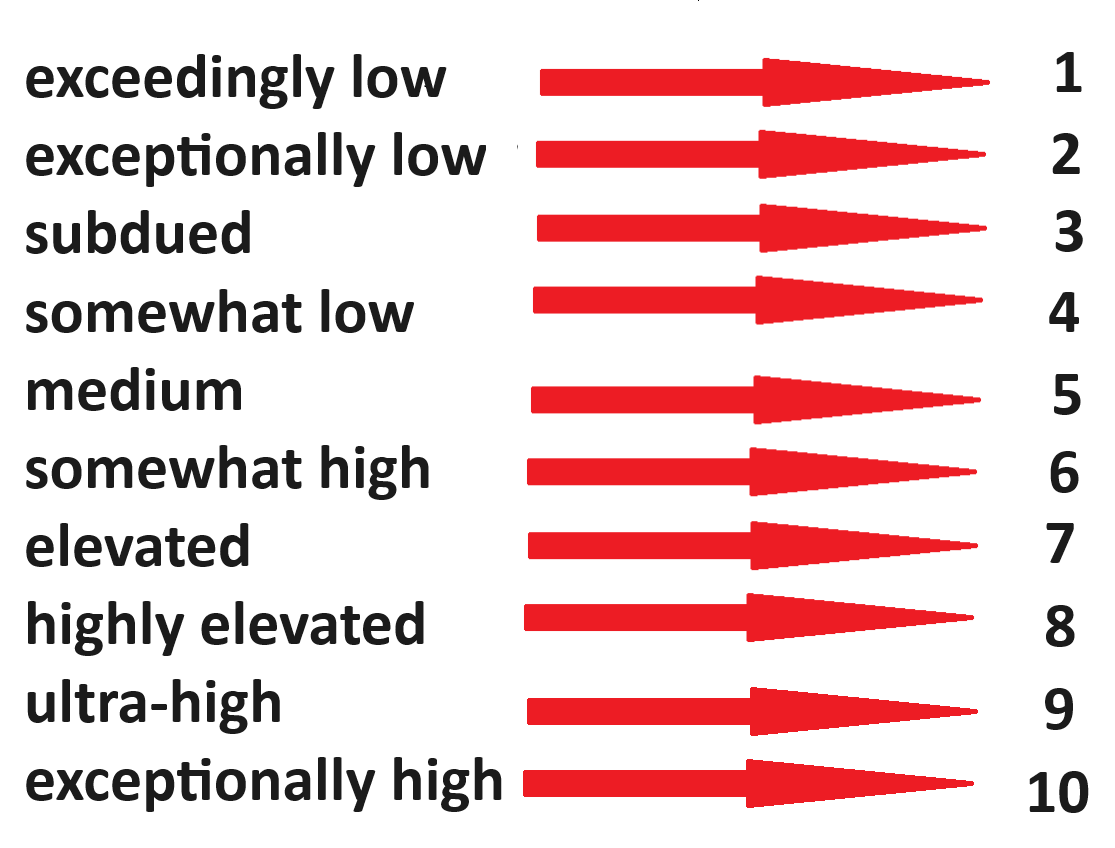

# **1. Classification**

In [16]:
# Make df_classification as a copy of df to avoid any changes in the original dataset

df_classification = df
df_classification.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,exceptionally low,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,somewhat low,United-States,<=50K
1,50,Self-emp-not-inc,exceptionally low,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,exceedingly low,United-States,<=50K
2,38,Private,exceedingly low,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,somewhat low,United-States,<=50K
3,53,Private,exceedingly low,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,somewhat low,United-States,<=50K
4,28,Private,subdued,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,somewhat low,Cuba,<=50K


Task (Mencoba alur split data terlebih dahulu kemudian preprocessing(handling missing value and feature engineering)):
1. Lakukan Split Dataset.
2. Lakukan preprocessing pada data training.
3. Lakukan preprocessing pada data testing.
4. Coba berbagai kernel pada model SVM.
5. Coba gunakan berbagai model ensemble learning dengan ketentuan 2 model bagging, 2 model boosting, dan 2 model stacking
6. Buat satu buah Table yang menampung semua perbanding hasil testing dengan model berbagai model.

## Split Data

In [17]:
# Importing train_test_split from sklearn to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split 

# Separate Features and Target
X = df_classification.drop(columns='income', axis=1) # Features by dropping the target column with axis 1 and saving it in X
Y = df_classification['income'] # Target column and saving it in Y

# Splitting the dataset into training and testing sets with 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X,Y, random_state=69, test_size=0.2)

## Training Data Preprocessing

In [18]:
# Make a object_col list to store the names of the columns that are of object type that will be encoded ordinally

object_col = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
    ]

In [19]:
# Importing OrdinalEncoder from sklearn to encode the object columns ordinally
from sklearn.preprocessing import OrdinalEncoder

# Encoding the object columns ordinally with OrdinalEncoder and saving it in enc with unknown values as -1 
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [20]:
# Encoding only the object_col columns in X_train 
X_train[object_col] = enc.fit_transform(X_train[object_col])

In [21]:
# Printing the all classes for fnlwgt and hours-per-week columns
labels

['exceptionally low',
 'exceedingly low',
 'subdued',
 'somewhat low',
 'medium',
 'somewhat high',
 'elevated',
 'highly elevated',
 'exceptionally high',
 'ultra-high']

In [22]:
# Map the fnlwgt and hours-per-week columns to the labels list with the mapping dictionary

mapping = {
    'exceptionally low': 1,
    'exceedingly low': 2,
    'subdued': 3,
    'somewhat low': 4,
    'medium': 5,
    'somewhat high': 6,
    'elevated': 7,
    'highly elevated': 8,
    'ultra-high': 9,
    'exceptionally high': 10}

In [23]:
X_train['fnlwgt'] = X_train['fnlwgt'].map(mapping) # Mapping fnlwgt column to the labels list with the mapping dictionary
X_train['hours-per-week'] = X_train['hours-per-week'].map(mapping) # Mapping hours-per-week column to the labels list with the mapping dictionary

## Testing Data Preprocessing

In [24]:
# Same as above for X_test but without fitting the encoder and only transforming the object_col columns

X_test[object_col] = enc.transform(X_test[object_col])
X_test['fnlwgt'] = X_test['fnlwgt'].map(mapping)
X_test['hours-per-week'] = X_test['hours-per-week'].map(mapping)

## SVM

In [32]:
# Importing SVC from sklearn to use Support Vector Classifier and GridSearchCV to find the best parameters for the model

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

#### Kernel Poly

In [33]:
SVM_class_poly = make_pipeline(StandardScaler(), SVC(kernel='poly', random_state=69)) # Making a pipeline with StandardScaler and SVC with kernel as poly and random_state as 69 
SVM_class_poly.fit(X_train, y_train) # Fitting the pipeline with X_train and y_train
SVM_pred_poly = SVM_class_poly.predict(X_test) # Predicting the target column with X_test and saving it in SVM_pred_poly

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, SVM_pred_poly))

              precision    recall  f1-score   support

       <=50K       0.86      0.95      0.90      4951
        >50K       0.76      0.51      0.61      1562

    accuracy                           0.85      6513
   macro avg       0.81      0.73      0.76      6513
weighted avg       0.84      0.85      0.83      6513



#### Kernel RBF

In [35]:
SVM_class_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=69))
SVM_class_rbf.fit(X_train, y_train)
SVM_pred_rbf = SVM_class_rbf.predict(X_test)

In [36]:
print(classification_report(y_test, SVM_pred_rbf))

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.90      4951
        >50K       0.76      0.54      0.63      1562

    accuracy                           0.85      6513
   macro avg       0.81      0.74      0.77      6513
weighted avg       0.84      0.85      0.84      6513



## Ensemble Learning

### Bagging (Decission Tree)

In [28]:
# Importing BaggindClassifier from sklearn to use BaggingClassifier Ensemble method
from sklearn.ensemble import BaggingClassifier
# Importing DecisionTreeClassifier from sklearn to use Decision Tree Classifier as the base estimator for BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Making a BaggingClassifier object with DecisionTreeClassifier as the base estimator and fitting it with the training data with n_estimators=10 and random_state=69
bag_class1 = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=69)

# Fitting the BaggingClassifier object with the training data
bag_class1.fit(X_train, y_train)

# Predicting the target column for the testing data (x_test) and saving it in bag_pred1
bag_pred1 = bag_class1.predict(X_test)

In [29]:
# Printing the classification report for bag_pred1
print(classification_report(y_test, bag_pred1))

              precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      4951
        >50K       0.70      0.58      0.63      1562

    accuracy                           0.84      6513
   macro avg       0.79      0.75      0.76      6513
weighted avg       0.83      0.84      0.83      6513



### Bagging (KNN)

In [30]:
# Importing KNeighborsClassifier from sklearn to use K Nearest Neighbors Classifier as the base estimator for BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Making a BaggingClassifier object with KNeighborsClassifier as the base estimator and fitting it with the training data with n_estimators=10 and random_state=69
bag_class2 = BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=10, random_state=69)

# Fitting the BaggingClassifier object with the training data
bag_class2.fit(X_train, y_train)

# Predicting the target column for the testing data (x_test) and saving it in bag_pred2
bag_pred2 = bag_class2.predict(X_test)

In [31]:
# Printing the classification report for bag_pred2
print(classification_report(y_test, bag_pred2))

              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      4951
        >50K       0.70      0.64      0.67      1562

    accuracy                           0.85      6513
   macro avg       0.79      0.77      0.78      6513
weighted avg       0.84      0.85      0.84      6513



### Boosting (Decission Tree)

In [32]:
# Importing AdaBoostClassifier from sklearn to use AdaBoost Classifier Ensemble method
from sklearn.ensemble import AdaBoostClassifier
# Importing DecisionTreeClassifier from sklearn to use Decision Tree Classifier as the base estimator for AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Making a AdaBoostClassifier object with DecisionTreeClassifier as the base estimator and fitting it with the training data with n_estimators=10 and random_state=69
boost_class1 = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=69)

# Fitting the AdaBoostClassifier object with the training data
boost_class1.fit(X_train, y_train)

# Predicting the target column for the testing data (x_test) and saving it in boost_pred1
boost_pred1 = boost_class1.predict(X_test)

In [33]:
print(classification_report(y_test, boost_pred1))

              precision    recall  f1-score   support

       <=50K       0.88      0.86      0.87      4951
        >50K       0.59      0.61      0.60      1562

    accuracy                           0.80      6513
   macro avg       0.73      0.74      0.74      6513
weighted avg       0.81      0.80      0.81      6513



### Boosting (Logistic Regression)

In [34]:
# Importing LogisticRegression from sklearn to use Logistic Regression as the base estimator for AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

# Making a AdaBoostClassifier object with LogisticRegression as the base estimator and fitting it with the training data with n_estimators=10 and random_state=69
boost_class2 = AdaBoostClassifier(estimator=LogisticRegression(), n_estimators=10, random_state=69)

# Fitting the AdaBoostClassifier object with the training data
boost_class2.fit(X_train, y_train)

# Predicting the target column for the testing data (x_test) and saving it in boost_pred2
boost_pred2 = boost_class2.predict(X_test)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mo

In [35]:
print(classification_report(y_test, boost_pred2))

              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88      4951
        >50K       0.67      0.32      0.43      1562

    accuracy                           0.80      6513
   macro avg       0.74      0.64      0.66      6513
weighted avg       0.78      0.80      0.77      6513



### Stacking

In [36]:
# Importing StackinClassifier from sklearn to use Stacking Classifier Ensemble method and random forest and SVC as the base estimators for StackingClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
# Importing LogisticRegression from sklearn to use Logistic Regression as the final estimator for StackingClassifier
from sklearn.linear_model import LogisticRegression
# Importing make_pipeline from sklearn to use make_pipeline to make a pipeline for SVC to scale the data before fitting it
from sklearn.pipeline import make_pipeline
# Importing SVC from sklearn to use Support Vector Classifier as the base estimator for StackingClassifier
from sklearn.svm import SVC
# Importing StandardScaler from sklearn to use StandardScaler to scale the data before fitting it
from sklearn.preprocessing import StandardScaler

# Making a list of tuples with the estimators for StackingClassifier (in this case it's random forest and SVC) and making a StackingClassifier object with LogisticRegression as the final estimator
estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('svc', make_pipeline(StandardScaler(),SVC(random_state=42)))
]

# Making a StackingClassifier object with the estimators list and LogisticRegression as the final estimator
stack_Class = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# Fitting the StackingClassifier object with the training data
stack_Class.fit(X_train,y_train)

StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(n_estimators=10,
                                                       random_state=42)),
                               ('svc',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(random_state=42))]))],
                   final_estimator=LogisticRegression())

In [37]:
# Predicting the target column for the testing data (x_test) and saving it in stack_pred1
stack_pred1 = stack_Class.predict(X_test)

# Printing the classification report for stack_pred1
print(classification_report(y_test, stack_pred1))

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4951
        >50K       0.77      0.57      0.65      1562

    accuracy                           0.85      6513
   macro avg       0.82      0.76      0.78      6513
weighted avg       0.85      0.85      0.85      6513



Contoh Table:


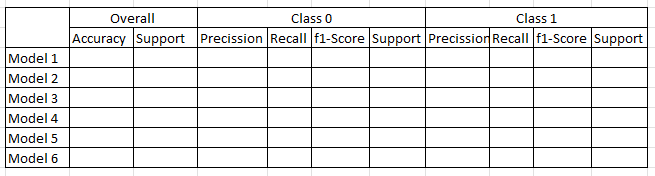

# **2. Clustering**

In [38]:
# Making df_clustering as a copy of df to avoid any changes in the original dataset and dropping the target column (income) from it to make it suitable for clustering
df_clustering = df.drop(['income'], axis=1)
df_clustering.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,exceptionally low,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,somewhat low,United-States
1,50,Self-emp-not-inc,exceptionally low,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,exceedingly low,United-States
2,38,Private,exceedingly low,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,somewhat low,United-States
3,53,Private,exceedingly low,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,somewhat low,United-States
4,28,Private,subdued,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,somewhat low,Cuba


Task:
1. Lakukan Feature Engineering
2. Coba 3 model Clustering seperti KMeans, DBSCAN, dan Hierarchical Clustering.
3. Pilih 3 feature sembarang atau yang ingin kalian gali informasinya lalu tampilkan perbedaan hasil dari 3 clustering model tersebut.


## Feature Engineering

In [39]:
# Importing OrdinalEncoder from sklearn to encode the object columns ordinally
from sklearn.preprocessing import OrdinalEncoder

# Encoding the object columns ordinally with OrdinalEncoder and saving it in enc with unknown values as -1
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Encoding all the columns in df_clustering
df_clustering[object_col] = enc.fit_transform(df_clustering[object_col])

# Encoding the fnlwgt and hours-per-week columns in df_clustering with the mapping dictionary made earlier
df_clustering['fnlwgt'] = df_clustering['fnlwgt'].map(mapping)
df_clustering['hours-per-week'] = df_clustering['hours-per-week'].map(mapping)

In [40]:
# CHECKING FOR NULL VALUES
df_clustering.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

## KMeans

### Search Best K

#### Elbow Method -> Search with the most kinkest elbow (Paling Bengkok)

In [41]:
# Use elbow method to find the optimal number of clusters

# Importing KMeans from sklearn to use KMeans clustering algorithm
from sklearn.cluster import KMeans

sse = [] #SUM OF SQUARED ERROR

# Looping through k values from 1 to 10 and fitting the KMeans object with the data and appending the inertia_ value to the sse list
for k in range(1,11):
    # Create a KMeans instance with k clusters: model, k being the number of clusters for each iteration
    km = KMeans(n_clusters=k, random_state=2)
    # Fit model to samples
    km.fit(df_clustering)
    # Append the inertia to the list of inertias
    sse.append(km.inertia_)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

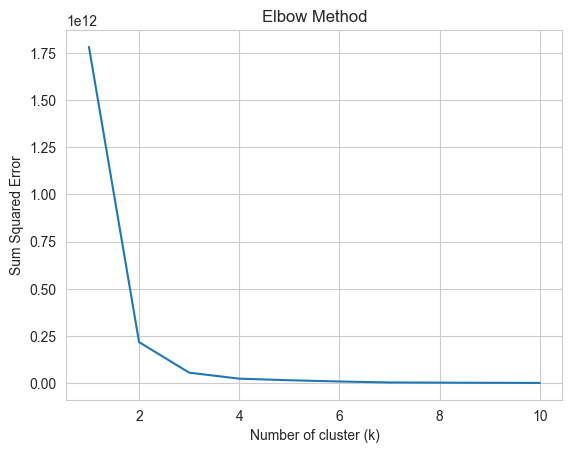

In [42]:
# Imporing seaborn to use seaborn's lineplot to plot the sse list
import seaborn as sns

# Plotting the sse list with seaborn's lineplot
sns.set_style("whitegrid")
g=sns.lineplot(x=range(1,11), y=sse)
 
g.set(xlabel ="Number of cluster (k)", 
      ylabel = "Sum Squared Error", 
      title ='Elbow Method')
 
plt.show()

#### Silhouette Method (DANGER -> LAMA BANGET) -> Search with the highest silhouette score

In [43]:
# Use silhouette score to find the optimal number of clusters

# Importing silhouette_score from sklearn to use silhouette_score to find the silhouette score for each k value
from sklearn.metrics import silhouette_score

sil = [] #SILHOUETTE SCORE

# Looping through k values from 2 to 10 and fitting the KMeans object with the data and appending the silhouette_score to the sil list

for k in range(2,11):
    # Create a KMeans instance with k clusters: model, k being the number of clusters for each iteration
    km = KMeans(n_clusters=k, random_state=2)
    # Fit model to samples
    km.fit(df_clustering)
    # Append the silhouette_score to the list of silhouettes
    sil.append(silhouette_score(df_clustering, km.labels_))

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

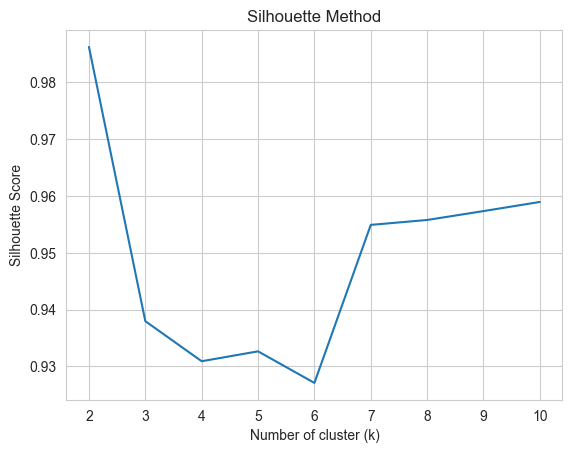

In [44]:
# Plotting the sil list with seaborn's lineplot
sns.set_style("whitegrid")

g=sns.lineplot(x=range(2,11), y=sil)

g.set(xlabel ="Number of cluster (k)",
        ylabel = "Silhouette Score",
        title ='Silhouette Method')

plt.show()

### Final KMeans Model

In [45]:
# Making a KMeans object with n_clusters=2 (based on the elbow method and silhouette method result) and random_state=25 and fitting it with the data
km = KMeans(random_state=25, n_clusters=2)

# Predicting the cluster labels for the data and saving it in km_pred
pred = km.fit_predict(df_clustering)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [55]:
# Importing plotly.express to use plotly's 3D scatter plot
import plotly.express as px

# Plotting the 3D scatter plot with plotly.express's scatter_3d
# x, y, and z are the columns that will be plotted -> can be changed to any other columns in the dataset based on the user's preference
px.scatter_3d(df_clustering, x='capital-gain', y='hours-per-week', z='fnlwgt', color=pred)

## DBSCAN

In [47]:
# Importing DBSCAN from sklearn to use DBSCAN clustering algorithm
from sklearn.cluster import DBSCAN

# Making a DBSCAN object and fitting it with the data
dbs = DBSCAN() # DBSCAN object
db_pred = dbs.fit_predict(df_clustering) # Fitting the DBSCAN object with the data and saving the cluster labels in db_pred

In [54]:
# Plotting the 3D scatter plot with plotly.express's scatter_3d
# x, y, and z are the columns that will be plotted -> can be changed to any other columns in the dataset based on the user's preference
px.scatter_3d(df_clustering, x='capital-gain', y='hours-per-week', z='fnlwgt', color=db_pred)

## Hierichical Model (Agglomerative Clustering)

In [52]:
# Importing AgglomerativeClustering from sklearn to use Agglomerative Clustering algorithm (Hierarchical Clustering)
from sklearn.cluster import AgglomerativeClustering

# Making a AgglomerativeClustering object with n_clusters=2 and affinity='euclidean' and linkage='ward' and fitting it with the data
agg = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')

# Predicting the cluster labels for the data and saving it in agg_pred
agg_pred = agg.fit_predict(df_clustering)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning:

Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead



ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'] but received: capita;-gain

In [53]:
# Plotting the 3D scatter plot with plotly.express's scatter_3d
# x, y, and z are the columns that will be plotted -> can be changed to any other columns in the dataset based on the user's preference
px.scatter_3d(df_clustering, x='capital-gain', y='hours-per-week', z='fnlwgt', color=agg_pred)

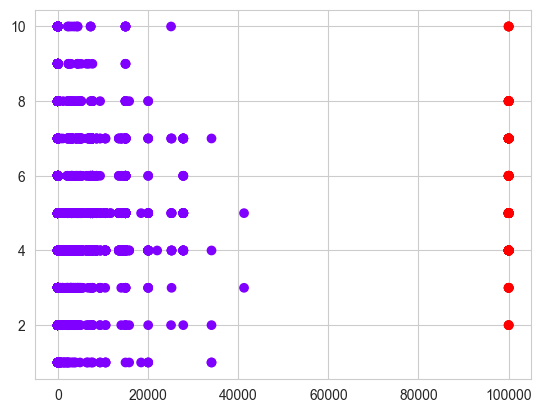

In [51]:
# 2d scatter plot for agg_pred
plt.scatter(df_clustering['capital-gain'], df_clustering['hours-per-week'], c=agg_pred, cmap='rainbow')